Total unique orders: 96477
Average Order Value: $159.86
Total revenue: $15,422,461.77
Unique clients: 93,357


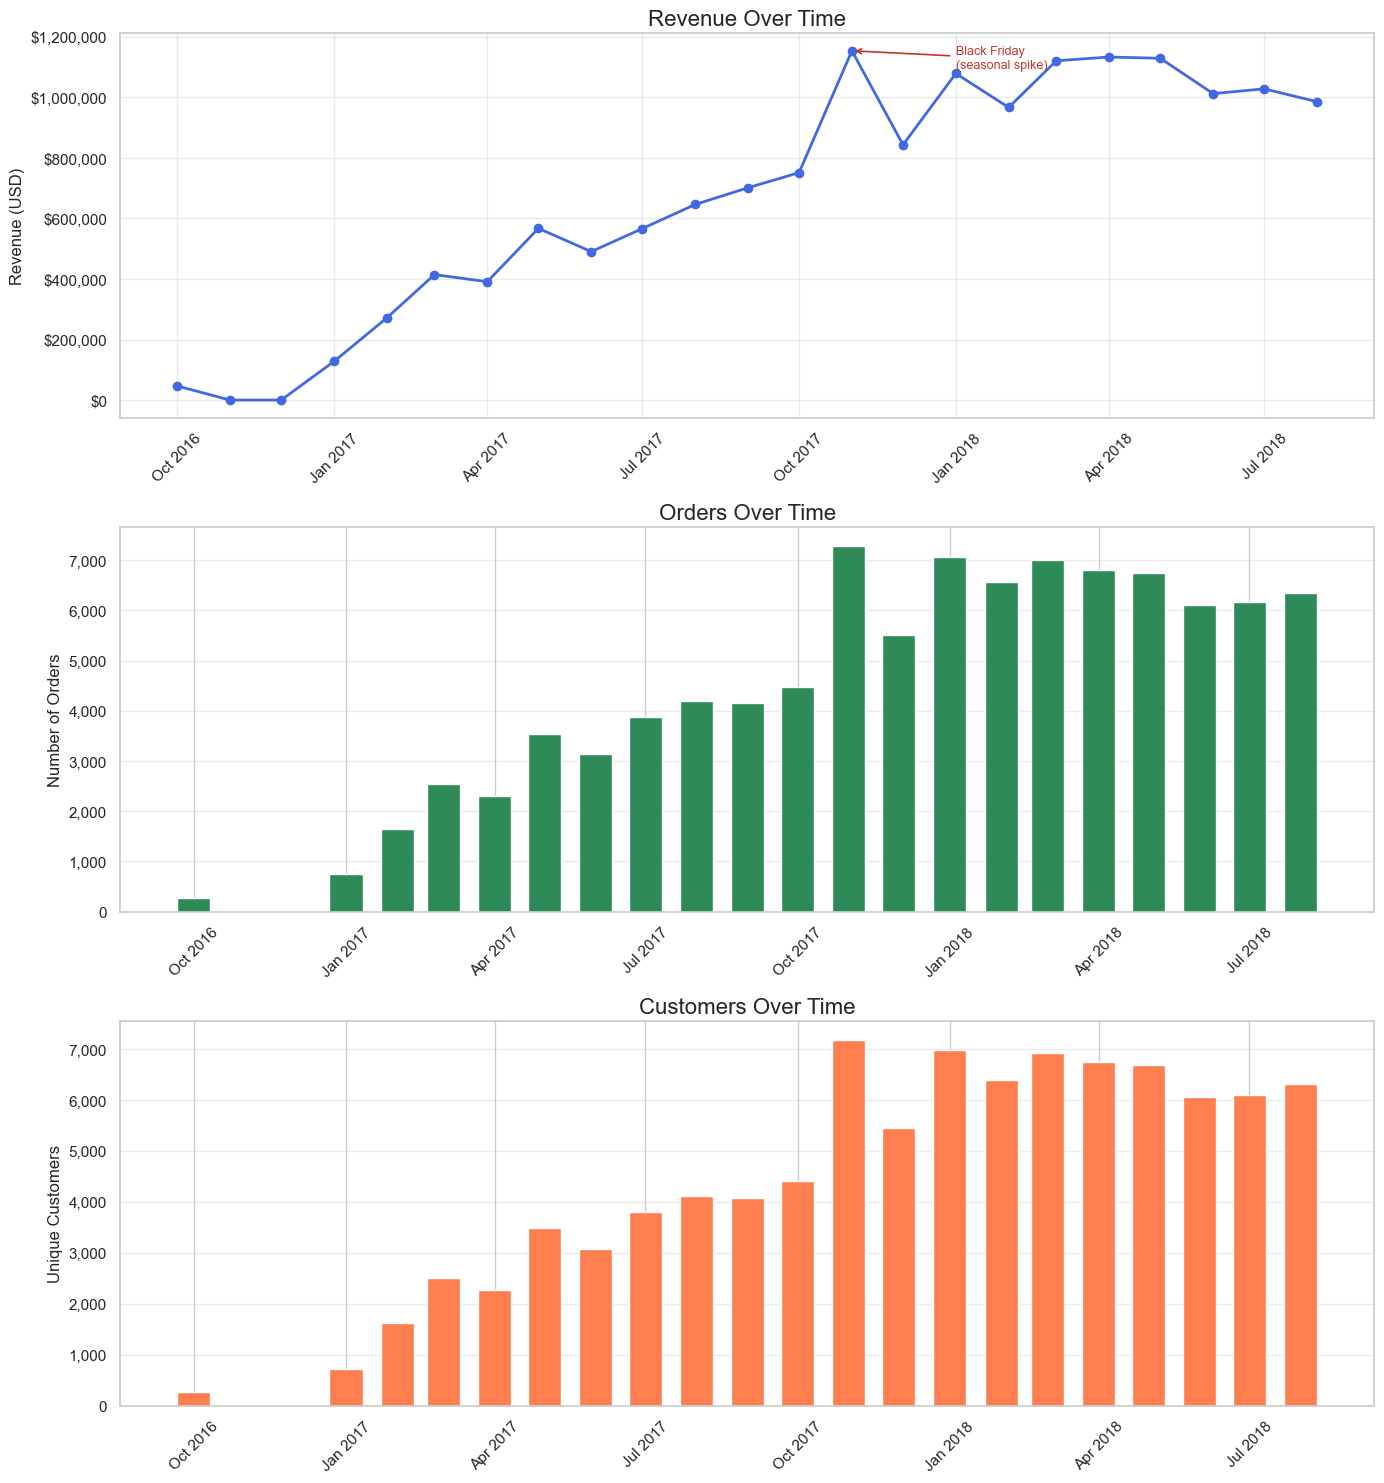


RFM Segment Stats:
        segment  customers  total_revenue  avg_revenue  revenue_share
           Lost      36093     5842442.93   161.871912      37.882687
VIP / Champions      15501     4752151.81   306.570661      30.813186
      Promising      39962     4333872.71   108.449845      28.101044
        At Risk        982      287219.13   292.483839       1.862343
          Loyal        819      206775.19   252.472759       1.340740


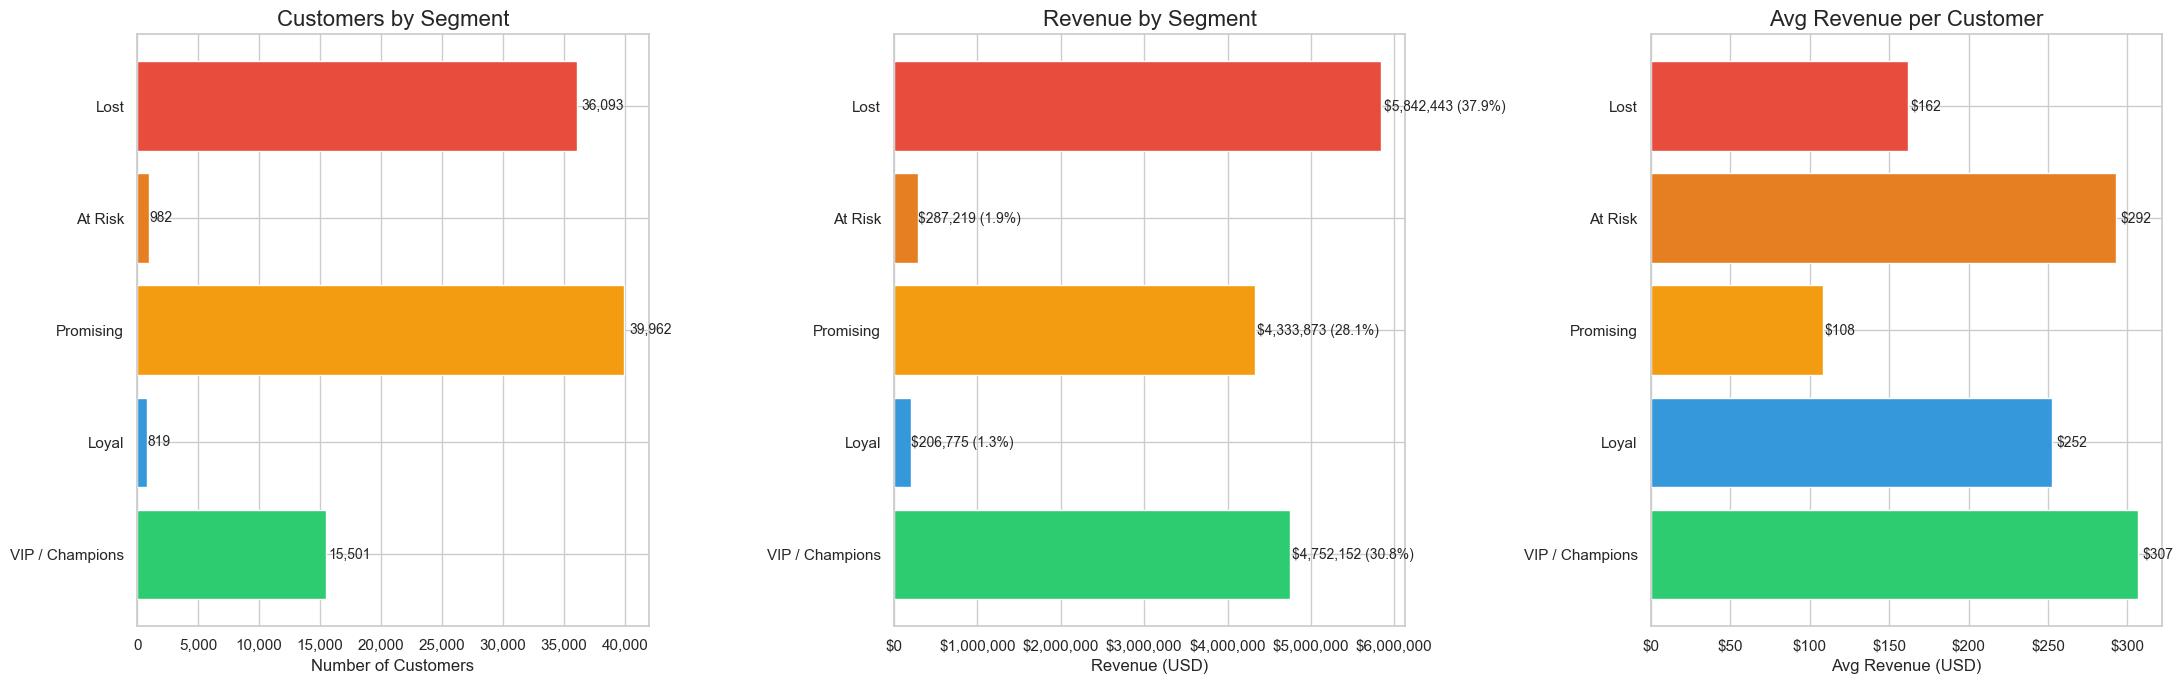


ABC Analysis:
                               category    revenue  revenue_share  cumulative_share abc
                          Health beauty 1411946.07       9.156809          9.156809   A
                          Watches gifts 1264333.12       8.199503         17.356312   A
                         Bed bath table 1225209.26       7.945776         25.302088   A
                         Sports leisure 1118256.91       7.252164         32.554252   A
                  Computers accessories 1032723.77       6.697461         39.251714   A
                        Furniture decor  880329.92       5.709151         44.960864   A
                             Housewares  758392.25       4.918356         49.879220   A
                             Cool stuff  691680.89       4.485716         54.364936   A
                                   Auto  669454.75       4.341575         58.706511   A
                           Garden tools  567145.68       3.678076         62.384587   A
                 

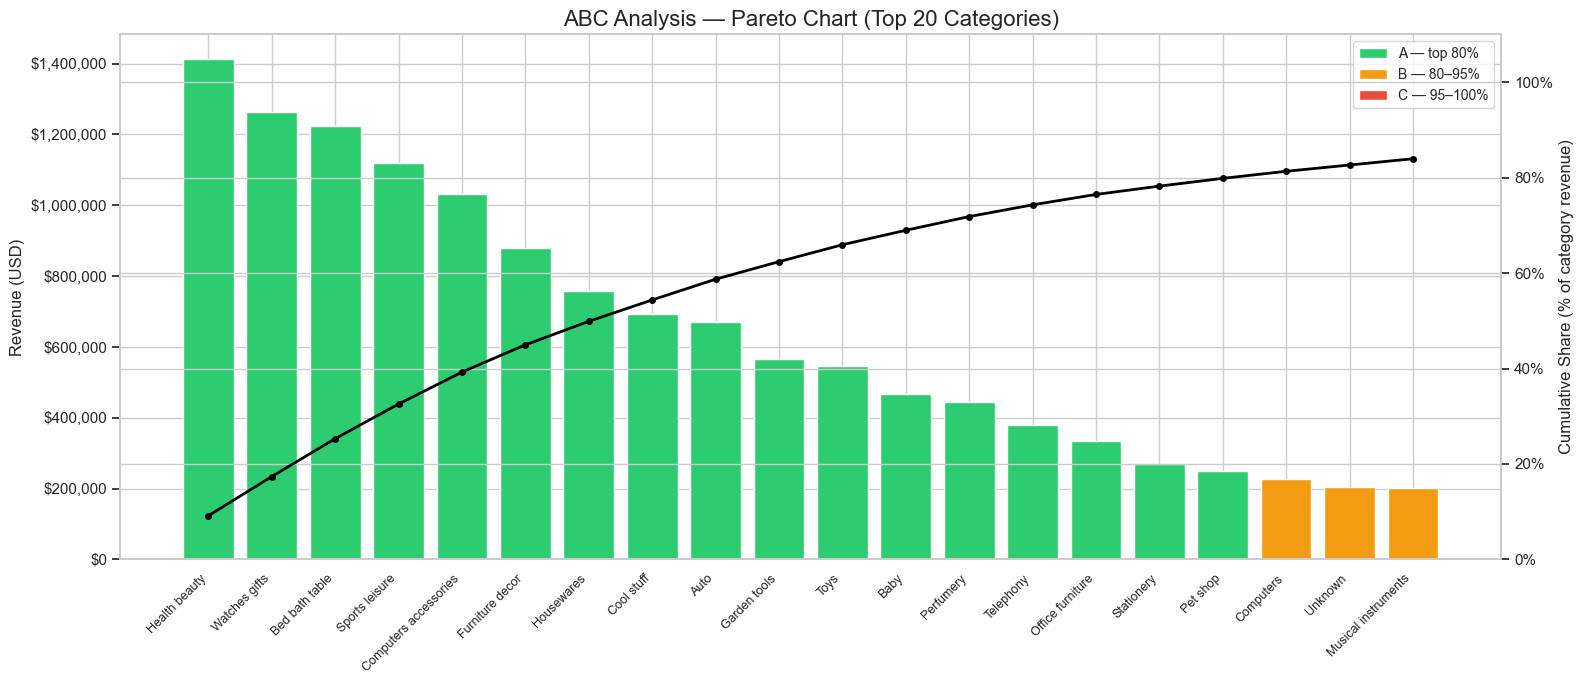

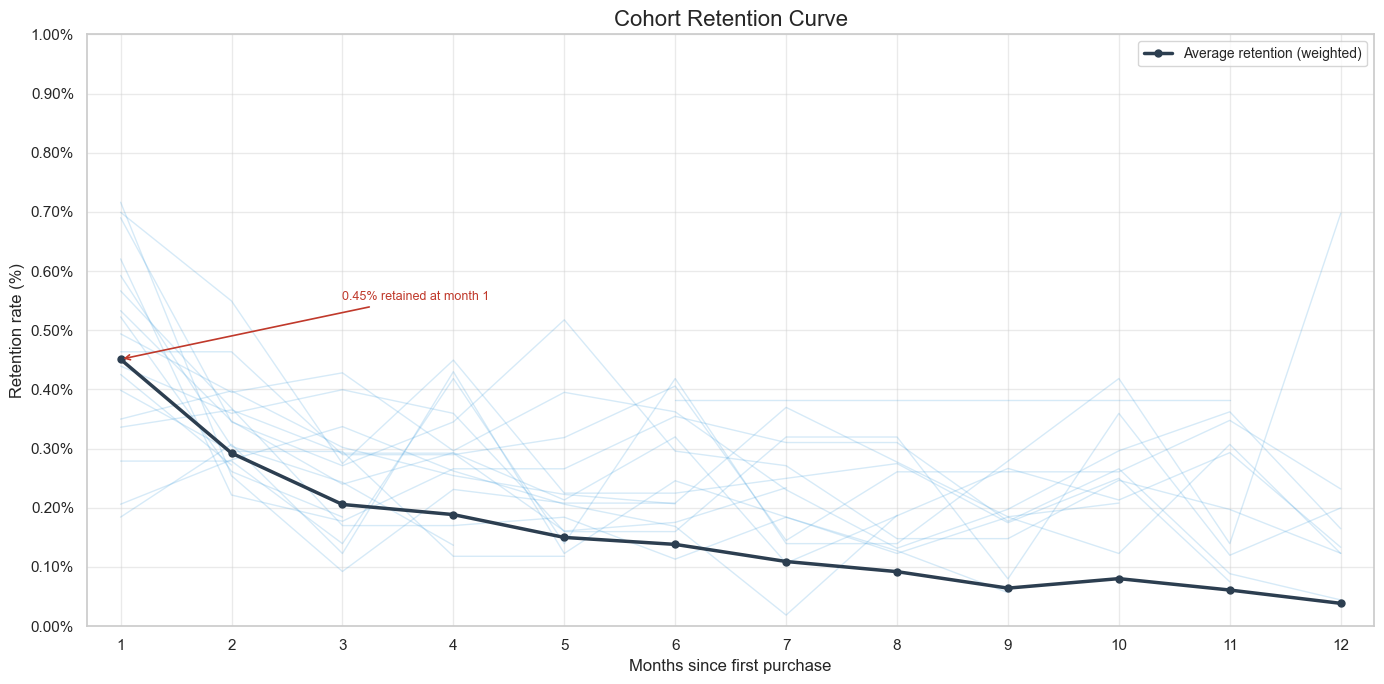


Average Retention by Period (weighted):
period
1     0.45%
2     0.29%
3     0.21%
4     0.19%
5     0.15%
6     0.14%
7     0.11%
8     0.09%
9     0.06%
10    0.08%
11    0.06%
12    0.04%
13    0.03%
14    0.02%
15    0.02%
16    0.01%
17    0.01%
19    0.00%
20    0.00%
dtype: object


In [ ]:
# 📌 Olist E-commerce Data Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")
# ==========================================
# LOAD DATASETS
# ==========================================
customers      = pd.read_csv('olist_customers_dataset.csv')
products       = pd.read_csv('olist_products_dataset.csv')
order_items    = pd.read_csv('olist_order_items_dataset.csv')
payments       = pd.read_csv('olist_order_payments_dataset.csv')
orders         = pd.read_csv('olist_orders_dataset.csv')
category_trans = pd.read_csv('product_category_name_translation.csv')
# ==========================================
# PREPROCESSING & MERGING
# ==========================================
orders = orders[orders['order_status'] == 'delivered']

payments_map = payments.groupby('order_id')['payment_value'].sum()

customer_map = customers.set_index('customer_id')['customer_unique_id']

df = pd.merge(orders, order_items, on='order_id', how='inner')
df['customer_unique_id'] = df['customer_id'].map(customer_map)
df['payment_value']      = df['order_id'].map(payments_map)
df = pd.merge(df, products[['product_id', 'product_category_name']], on='product_id', how='left')
df = pd.merge(df, category_trans, on='product_category_name', how='left')

df.dropna(subset=['payment_value'], inplace=True)
df = df[df['payment_value'] > 0]

df['product_category_name_english'] = (
    df['product_category_name_english']
    .str.replace('_', ' ')
    .str.capitalize()
    .fillna('Unknown')
)

for col in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    df[col] = pd.to_datetime(df[col])

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df = df.drop(columns=['product_category_name'])

# ==========================================
# KPI
# ==========================================

orders_unique = df.drop_duplicates('order_id').copy()

total_revenue          = orders_unique['payment_value'].sum()
aov                    = orders_unique['payment_value'].mean()
unique_customers_total = orders_unique['customer_unique_id'].nunique()
total_orders           = orders_unique['order_id'].nunique()

print(f"Total unique orders: {total_orders}")
print(f"Average Order Value: ${aov:.2f}")
print(f"Total revenue: ${total_revenue:,.2f}")
print(f"Unique clients: {unique_customers_total:,}")

# ==========================================
# REVENUE / ORDERS / CUSTOMERS OVER TIME
# ==========================================

time_agg = (
    orders_unique
    .groupby(pd.Grouper(key='order_purchase_timestamp', freq='MS'))
    .agg(
        revenue         =('payment_value',      'sum'),
        unique_customers=('customer_unique_id', 'nunique'),
        order_count     =('order_id',           'count')
    )
    .loc['2016-09':'2018-08']
)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 15))

ax1.plot(time_agg.index, time_agg['revenue'],
         marker='o', linestyle='-', color='royalblue', linewidth=2)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.tick_params(axis='x', rotation=45)
ax1.set_title("Revenue Over Time", fontsize=16)
ax1.set_ylabel("Revenue (USD)", fontsize=12)
ax1.grid(True, alpha=0.4)

nov_2017 = pd.Timestamp('2017-11-01')
if nov_2017 in time_agg.index and time_agg.loc[nov_2017, 'revenue'] > 0:
    ax1.annotate(
        'Black Friday\n(seasonal spike)',
        xy=(nov_2017, time_agg.loc[nov_2017, 'revenue']),
        xytext=(nov_2017 + pd.DateOffset(months=2), time_agg.loc[nov_2017, 'revenue'] * 0.95),
        fontsize=9, color='#c0392b',
        arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2),
        ha='left'
    )

ax2.bar(time_agg.index, time_agg['order_count'], color='seagreen', width=20)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.tick_params(axis='x', rotation=45)
ax2.set_title("Orders Over Time", fontsize=16)
ax2.set_ylabel("Number of Orders", fontsize=12)
ax2.grid(True, alpha=0.4, axis='y')

ax3.bar(time_agg.index, time_agg['unique_customers'], color='coral', width=20)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.tick_params(axis='x', rotation=45)
ax3.set_title("Customers Over Time", fontsize=16)
ax3.set_ylabel("Unique Customers", fontsize=12)
ax3.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

# ==========================================
# RFM
# ==========================================

snapshot_date = pd.Timestamp('2018-09-01')  

rfm = orders_unique.groupby('customer_unique_id').agg(
    recency  =('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id',                'count'),
    monetary =('payment_value',           'sum')
).reset_index()

rfm['R'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1])

rfm['F'] = np.select(
    [rfm['frequency'] == 1, rfm['frequency'] == 2, rfm['frequency'] == 3],
    [1, 2, 4],
    default=5
)

rfm['M'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

def segment(row):
    r, f, m = int(row['R']), int(row['F']), int(row['M'])
    if r >= 4 and (f >= 4 or m >= 4):  return 'VIP / Champions'
    elif r >= 3 and f >= 2:             return 'Loyal'
    elif r >= 3 and f == 1:             return 'Promising'
    elif r <= 2 and f >= 2:             return 'At Risk'
    else:                               return 'Lost'

rfm['segment'] = rfm.apply(segment, axis=1)

segment_stats = rfm.groupby('segment').agg(
    customers    =('customer_unique_id', 'count'),
    total_revenue=('monetary',           'sum'),
    avg_revenue  =('monetary',           'mean')
).reset_index()

segment_stats['revenue_share'] = (
    segment_stats['total_revenue'] / segment_stats['total_revenue'].sum() * 100
)
segment_stats = segment_stats.sort_values('total_revenue', ascending=False)

print("\nRFM Segment Stats:")
print(segment_stats.to_string(index=False))

# ==========================================
# RFM VISUALIZATION
# ==========================================
segment_order  = ['VIP / Champions', 'Loyal', 'Promising', 'At Risk', 'Lost']
segment_colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
color_map      = dict(zip(segment_order, segment_colors))

plot_data = segment_stats.set_index('segment').reindex(segment_order).dropna()
colors    = [color_map[s] for s in plot_data.index]

def plot_rfm_bar(ax, values, labels, colors, title, xlabel, fmt_fn, label_fn):
    bars = ax.barh(labels, values, color=colors)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_fn))
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() * 1.01,
            bar.get_y() + bar.get_height() / 2,
            label_fn(val), va='center', fontsize=10
        )

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

plot_rfm_bar(ax1, plot_data['customers'], plot_data.index, colors,
             "Customers by Segment", "Number of Customers",
             lambda x, _: f'{x:,.0f}',
             lambda v: f'{v:,.0f}')

bars2 = ax2.barh(plot_data.index, plot_data['total_revenue'], color=colors)
ax2.set_title("Revenue by Segment", fontsize=16)
ax2.set_xlabel("Revenue (USD)", fontsize=12)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, (val, share) in zip(bars2, zip(plot_data['total_revenue'], plot_data['revenue_share'])):
    ax2.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height() / 2,
             f'${val:,.0f} ({share:.1f}%)', va='center', fontsize=10)

plot_rfm_bar(ax3, plot_data['avg_revenue'], plot_data.index, colors,
             "Avg Revenue per Customer", "Avg Revenue (USD)",
             lambda x, _: f'${x:,.0f}',
             lambda v: f'${v:,.0f}')

plt.tight_layout()
plt.show()

# ==========================================
# ABC ANALYSIS
# ==========================================
df['item_revenue'] = df['price'] + df['freight_value']

category_revenue = (
    df.groupby('product_category_name_english')['item_revenue']
    .sum().sort_values(ascending=False).reset_index()
)
category_revenue.columns = ['category', 'revenue']

total_cat_revenue                    = category_revenue['revenue'].sum()
category_revenue['revenue_share']    = category_revenue['revenue'] / total_cat_revenue * 100
category_revenue['cumulative_share'] = category_revenue['revenue_share'].cumsum()

category_revenue['abc'] = pd.cut(
    category_revenue['cumulative_share'],
    bins=[0, 80, 95, 100],
    labels=['A', 'B', 'C']
)

print("\nABC Analysis:")
print(category_revenue[['category', 'revenue', 'revenue_share', 'cumulative_share', 'abc']].to_string(index=False))

top_n      = 20
plot_abc   = category_revenue.head(top_n).copy()
abc_colors = plot_abc['abc'].map({'A': '#2ecc71', 'B': '#f39c12', 'C': '#e74c3c'})

fig, ax1 = plt.subplots(figsize=(16, 7))
bars = ax1.bar(range(top_n), plot_abc['revenue'], color=abc_colors)
ax1.set_xticks(range(top_n))
ax1.set_xticklabels(plot_abc['category'], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel("Revenue (USD)", fontsize=12)
ax1.set_title("ABC Analysis — Pareto Chart (Top 20 Categories)", fontsize=16)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(range(top_n), plot_abc['cumulative_share'], color='black',
         marker='o', linewidth=2, markersize=4)
ax2.set_ylabel("Cumulative Share (% of category revenue)", fontsize=12)
ax2.set_ylim(0, 110)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

legend_elements = [
    Patch(facecolor='#2ecc71', label='A — top 80%'),
    Patch(facecolor='#f39c12', label='B — 80–95%'),
    Patch(facecolor='#e74c3c', label='C — 95–100%')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================
# COHORT RETENTION CURVE
# ==========================================

cohort_map    = df.groupby('customer_unique_id')['order_month'].min()
df['cohort']  = df['customer_unique_id'].map(cohort_map)

cohort_data = (
    df.groupby(['cohort', 'order_month'])['customer_unique_id']
    .nunique().reset_index()
)

cohort_data['period'] = (
    cohort_data['order_month'] - cohort_data['cohort']
).apply(lambda x: x.n)

cohort_table = (
    cohort_data.groupby(['cohort', 'period'])['customer_unique_id']
    .sum().unstack('period')
)

cohort_sizes = cohort_table[0]
retention    = cohort_table.divide(cohort_sizes, axis=0)

weighted_retention = (
    cohort_table.iloc[:, 1:]
    .divide(cohort_sizes, axis=0)
    .multiply(cohort_sizes, axis=0)
    .sum()
    .divide(cohort_sizes.sum())
)

retention_plot = retention.loc[:, 0:12]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

for cohort_idx in retention_plot.index:
    values = retention_plot.loc[cohort_idx].drop(0, errors='ignore').dropna()
    if len(values) > 1:
        ax.plot(values.index, values.values * 100,
                color='#3498db', alpha=0.2, linewidth=1)

periods    = list(weighted_retention.index[:12])
avg_values = list(weighted_retention.values[:12] * 100)

ax.plot(periods, avg_values,
        color='#2c3e50', linewidth=2.5,
        marker='o', markersize=5, label='Average retention (weighted)')

ax.annotate(
    f"{weighted_retention.iloc[0]*100:.2f}% retained at month 1",
    xy=(1, weighted_retention.iloc[0] * 100),
    xytext=(3, weighted_retention.iloc[0] * 100 + 0.1),
    fontsize=9, color='#c0392b',
    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2)
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}%'))
ax.set_xlim(0.7, 12.3)
ax.set_ylim(0, 1.0)
ax.set_yticks([i * 0.1 for i in range(11)])
ax.set_xticks(range(1, 13))
ax.set_xlabel("Months since first purchase", fontsize=12)
ax.set_ylabel("Retention rate (%)", fontsize=12)
ax.set_title("Cohort Retention Curve", fontsize=16)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print("\nAverage Retention by Period (weighted):")
print(weighted_retention.apply(lambda x: f'{x:.2%}'))